# CST8509 Week 2: Markov Decision Processes - Complete Demo

Demonstrates core MDP concepts from Week 2:
- MDP five-tuple formal definition (Sutton §3.1; Silver L2 Slide 24)
- SARSA vs Q-Learning comparison on CliffWalking (Sutton §6.4-6.5)
- On-policy vs Off-policy path difference
- Reward design experiments (negative/zero/positive per-step rewards)
- Discount factor γ effect on return and agent behavior
- Bellman equation step-by-step verification
- Policy and value function visualization

In [1]:
import os
import sys
import random
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from datetime import datetime

# Set up utf-8 encoding for Windows terminal
try:
    if sys.platform == 'win32':
        sys.stdout.reconfigure(encoding='utf-8')
except AttributeError:
    pass  # Jupyter kernel doesn't support reconfigure

## Environment Setup

In [2]:
# ============================================================
# 环境配置
# Environment Setup
# ============================================================
load_dotenv(os.path.join(os.getcwd(), '.env.local'))  # Jupyter: explicit path
STUDENT_NAME = os.getenv('NAME', 'Peng Wang')
STUDENT_NUMBER = os.getenv('NUMBER', '041107730')

# 输出目录（保存可视化图片）
# Output directory for saving visualization images
SCRIPT_DIR = os.getcwd()  # Jupyter: use cwd instead of __file__
OUTPUT_DIR = os.path.join(SCRIPT_DIR, 'week2_mdp_complete_demo_pages')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 随机种子（确保可复现）
# Random seed for reproducibility
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# 图表样式
# Plot style configuration
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("=" * 60)
print(f"CST8509 Week 2: Markov Decision Processes")
print(f"Author: {STUDENT_NAME} ({STUDENT_NUMBER})")
print(f"Date: {datetime.now().strftime('%Y-%m-%d')}")
print("=" * 60)

CST8509 Week 2: Markov Decision Processes
Author: Peng Wang (041107730)
Date: 2026-02-26


## Cliff Walking Environment Definition

In [3]:
# ============================================================
# Cliff Walking 环境定义
# Cliff Walking Environment Definition
# ============================================================
# Cliff Walking 是 Sutton & Barto 经典环境（Example 6.6）
# 4x12 网格，底行有悬崖，掉入悬崖 -100 并回到起点
# Cliff Walking is a classic environment from Sutton & Barto (Example 6.6)
# 4x12 grid, bottom row has cliff, falling off cliff = -100 and reset to start

CLIFF_ROWS = 4
CLIFF_COLS = 12
CLIFF_START = (3, 0)
CLIFF_GOAL = (3, 11)
NUM_STATES = CLIFF_ROWS * CLIFF_COLS
NUM_ACTIONS = 4

# 动作定义：上(0)、下(1)、左(2)、右(3)
# Action definitions: up(0), down(1), left(2), right(3)
ACTIONS = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}
ACTION_NAMES = {0: 'Up', 1: 'Down', 2: 'Left', 3: 'Right'}
ARROW_SYMBOLS = {0: '↑', 1: '↓', 2: '←', 3: '→'}


def state_to_idx(row, col):
    """二维坐标 → 一维索引 / 2D coordinate to 1D index."""
    return row * CLIFF_COLS + col


def idx_to_state(idx):
    """一维索引 → 二维坐标 / 1D index to 2D coordinate."""
    return idx // CLIFF_COLS, idx % CLIFF_COLS


def cliff_step(state_idx, action, step_reward=-1):
    """Cliff Walking 环境的一步转移 / One step in Cliff Walking environment.

    Args:
        state_idx: 当前状态索引 / Current state index
        action: 动作索引 / Action index (0=up, 1=down, 2=left, 3=right)
        step_reward: 每步奖励 / Per-step reward (default -1)

    Returns:
        (next_state, reward, done) — MDP 转移三元组 / MDP transition triple
    """
    row, col = idx_to_state(state_idx)
    dr, dc = ACTIONS[action]
    new_row = max(0, min(CLIFF_ROWS - 1, row + dr))
    new_col = max(0, min(CLIFF_COLS - 1, col + dc))

    # 检查是否掉入悬崖（底行，第1-10列）
    # Check if fell off cliff (bottom row, columns 1-10)
    if new_row == 3 and 1 <= new_col <= 10:
        return state_to_idx(*CLIFF_START), -100, False

    next_idx = state_to_idx(new_row, new_col)
    if (new_row, new_col) == CLIFF_GOAL:
        return next_idx, 0, True    # 到达目标 / Reached goal

    return next_idx, step_reward, False  # 普通移动 / Normal move


def epsilon_greedy(q_table, state, epsilon, num_actions=NUM_ACTIONS):
    """ε-贪婪动作选择 / Epsilon-greedy action selection.

    📚 Ref: Sutton §2.2 — ε-greedy balances exploration and exploitation.
    - With probability ε: random action (探索 / exploration)
    - With probability 1-ε: argmax Q(s,a) (利用 / exploitation)
    """
    if random.random() < epsilon:
        return random.choice(range(num_actions))
    return np.argmax(q_table[state])


def rolling_mean(data, window):
    """计算滑动平均 / Compute rolling average."""
    return [np.mean(data[max(0, i - window):i + 1]) for i in range(len(data))]

## Step 1: MDP Five-Tuple Formal Definition

In [4]:
# ============================================================
# 步骤 1：MDP 五元组正式定义
# Step 1: MDP Five-Tuple Formal Definition
# ============================================================
# 📚 Ref: Sutton §3.1, p.47-49; David Silver L2 Slide 24
# MDP = ⟨S, A, P, R, γ⟩
# Sutton notation: p(s', r | s, a) — bundles transition and reward
# Silver notation: P^a_{ss'}, R^a_s — separates transition and reward

print("\n" + "=" * 60)
print("Step 1: MDP Five-Tuple Definition <S, A, P, R, gamma>")
print("=" * 60)

print(f"""
MDP for CliffWalking:
  S = {{0, 1, ..., {NUM_STATES - 1}}}  ({CLIFF_ROWS}×{CLIFF_COLS} = {NUM_STATES} states)
  A = {{Up, Down, Left, Right}}  ({NUM_ACTIONS} actions)
  P = p(s', r | s, a)  — deterministic transitions (one-hot probabilities)
  R = {{-100, -1, 0}}  — cliff, step, goal
  γ ∈ [0, 1)  — discount factor (we'll use 0.9)

Sutton notation:  p(s', r | s, a) = P(S_t=s', R_t=r | S_{{t-1}}=s, A_{{t-1}}=a)
Silver notation:  P^a_{{ss'}} = P[S_{{t+1}}=s' | S_t=s, A_t=a],  R^a_s = E[R_{{t+1}} | S_t=s, A_t=a]
""")

# 展示几个具体的转移概率
# Show some concrete transition probabilities
test_cases = [
    (state_to_idx(2, 5), 1, "State (2,5) + Down"),   # 掉入悬崖
    (state_to_idx(2, 5), 3, "State (2,5) + Right"),   # 正常移动
    (state_to_idx(3, 10), 3, "State (3,10) + Right"),  # 到达目标
]

print("Example transitions p(s', r | s, a):")
print(f"{'Description':<25} | {'s':>3} | {'a':>5} | {'s_next':>6} | {'r':>5} | {'done':>5}")
print("-" * 65)
for s, a, desc in test_cases:
    ns, r, done = cliff_step(s, a)
    print(f"{desc:<25} | {s:>3} | {ACTION_NAMES[a]:>5} | {ns:>6} | {r:>5} | {str(done):>5}")


Step 1: MDP Five-Tuple Definition <S, A, P, R, gamma>

MDP for CliffWalking:
  S = {0, 1, ..., 47}  (4×12 = 48 states)
  A = {Up, Down, Left, Right}  (4 actions)
  P = p(s', r | s, a)  — deterministic transitions (one-hot probabilities)
  R = {-100, -1, 0}  — cliff, step, goal
  γ ∈ [0, 1)  — discount factor (we'll use 0.9)

Sutton notation:  p(s', r | s, a) = P(S_t=s', R_t=r | S_{t-1}=s, A_{t-1}=a)
Silver notation:  P^a_{ss'} = P[S_{t+1}=s' | S_t=s, A_t=a],  R^a_s = E[R_{t+1} | S_t=s, A_t=a]

Example transitions p(s', r | s, a):
Description               |   s |     a | s_next |     r |  done
-----------------------------------------------------------------
State (2,5) + Down        |  29 |  Down |     36 |  -100 | False
State (2,5) + Right       |  29 | Right |     30 |    -1 | False
State (3,10) + Right      |  46 | Right |     47 |     0 |  True


## Step 2: SARSA vs Q-Learning Core Comparison

In [5]:
# ============================================================
# 步骤 2：SARSA vs Q-Learning 核心对比
# Step 2: SARSA vs Q-Learning Core Comparison
# ============================================================
# 📚 Ref: Sutton §6.4 (SARSA) and §6.5 (Q-Learning)
# 核心区别：
#   Q-Learning: Q(S,A) += α[R + γ max_a' Q(S',a') - Q(S,A)]  — Off-policy
#   SARSA:      Q(S,A) += α[R + γ Q(S',A') - Q(S,A)]          — On-policy
# Q-Learning 用 max（假设最终贪婪执行），SARSA 用实际选的 A'（考虑探索风险）

print("\n" + "=" * 60)
print("Step 2: SARSA vs Q-Learning Comparison")
print("=" * 60)

# 超参数
# Hyperparameters
EPISODES = 500
GAMMA = 0.9
ALPHA = 0.1
EPSILON_START = 1.0
EPSILON_MIN = 0.01
EPSILON_DECAY = 0.995
MAX_STEPS = 500


def train_q_learning(episodes=EPISODES, gamma=GAMMA, alpha=ALPHA,
                     eps_start=EPSILON_START, eps_min=EPSILON_MIN,
                     eps_decay=EPSILON_DECAY, step_reward=-1):
    """Train Q-Learning agent (off-policy TD control).

    📚 Ref: Sutton §6.5, p.131 — Q-Learning update uses max_a' Q(S', a'),
    which approximates the Bellman optimality equation for q* (Sutton Eq. 3.20;
    Silver L2 Slide 46).
    """
    q = np.zeros((NUM_STATES, NUM_ACTIONS))
    eps = eps_start
    rewards_log = []
    steps_log = []

    for ep in range(episodes):
        s = state_to_idx(*CLIFF_START)
        done = False
        ep_reward = 0
        steps = 0

        while not done and steps < MAX_STEPS:
            steps += 1
            a = epsilon_greedy(q, s, eps)
            ns, r, done = cliff_step(s, a, step_reward)
            ep_reward += r

            # Q-Learning 更新：用 max Q(S', a') — off-policy
            # Q-Learning update: use max Q(S', a') — off-policy
            td_target = r + gamma * np.max(q[ns])
            q[s][a] += alpha * (td_target - q[s][a])
            s = ns

        rewards_log.append(ep_reward)
        steps_log.append(steps)
        eps = max(eps_min, eps * eps_decay)

    return q, rewards_log, steps_log


def train_sarsa(episodes=EPISODES, gamma=GAMMA, alpha=ALPHA,
                eps_start=EPSILON_START, eps_min=EPSILON_MIN,
                eps_decay=EPSILON_DECAY, step_reward=-1):
    """Train SARSA agent (on-policy TD control).

    📚 Ref: Sutton §6.4, p.129 — SARSA update uses Q(S', A'), where A' is the
    actual next action chosen by the SAME ε-greedy policy.
    Name origin: (S, A, R, S', A') — the quintuple needed for each update.
    """
    q = np.zeros((NUM_STATES, NUM_ACTIONS))
    eps = eps_start
    rewards_log = []
    steps_log = []

    for ep in range(episodes):
        s = state_to_idx(*CLIFF_START)
        done = False
        ep_reward = 0
        steps = 0

        # SARSA 特有：在循环前先选动作 A
        # SARSA-specific: choose initial action A before loop
        a = epsilon_greedy(q, s, eps)

        while not done and steps < MAX_STEPS:
            steps += 1
            ns, r, done = cliff_step(s, a, step_reward)
            ep_reward += r

            # SARSA 特有：从 S' 选择 A'（用同一个 ε-greedy 策略）
            # SARSA-specific: choose A' from S' using SAME ε-greedy policy
            na = epsilon_greedy(q, ns, eps)

            # SARSA 更新：用 Q(S', A') — on-policy
            # SARSA update: use Q(S', A') — on-policy
            td_target = r + gamma * q[ns][na]
            q[s][a] += alpha * (td_target - q[s][a])

            s = ns
            a = na  # SARSA 特有：下一步用 A' 作为当前动作

        rewards_log.append(ep_reward)
        steps_log.append(steps)
        eps = max(eps_min, eps * eps_decay)

    return q, rewards_log, steps_log


print(f"Training both agents on CliffWalking ({EPISODES} episodes)...")
print(f"  γ={GAMMA}, α={ALPHA}, ε: {EPSILON_START}→{EPSILON_MIN}")

q_ql, rewards_ql, steps_ql = train_q_learning()
q_sarsa, rewards_sarsa, steps_sarsa = train_sarsa()

print(f"\nResults (last 30 episodes):")
print(f"  Q-Learning: avg reward = {np.mean(rewards_ql[-30:]):.1f}, avg steps = {np.mean(steps_ql[-30:]):.1f}")
print(f"  SARSA:      avg reward = {np.mean(rewards_sarsa[-30:]):.1f}, avg steps = {np.mean(steps_sarsa[-30:]):.1f}")


Step 2: SARSA vs Q-Learning Comparison
Training both agents on CliffWalking (500 episodes)...
  γ=0.9, α=0.1, ε: 1.0→0.01



Results (last 30 episodes):
  Q-Learning: avg reward = -48.5, avg steps = 16.5
  SARSA:      avg reward = -503.3, avg steps = 500.0


## Step 3: Visualization — Learning Curve Comparison


Step 3: Learning Curves — SARSA vs Q-Learning


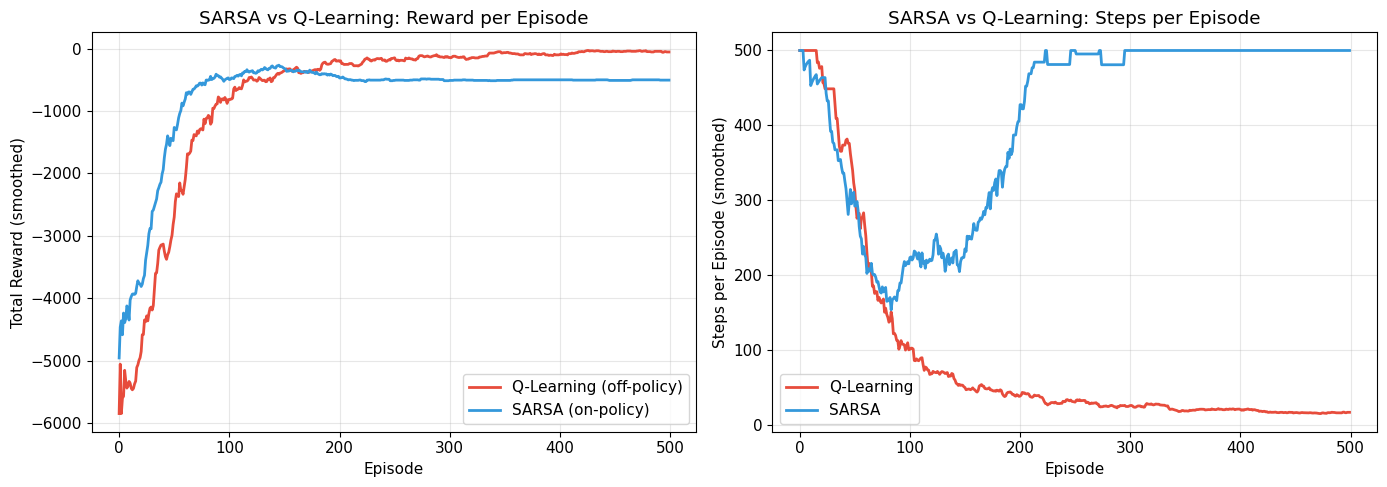

Saved: C:\Users\40270\OneDrive\Desktop\workspace\aisd\courses\rl\notes\week2_mdp_complete_demo_pages\fig1_sarsa_vs_qlearning_curves.png


In [6]:
# ============================================================
# 步骤 3：可视化 — 学习曲线对比
# Step 3: Visualization — Learning Curve Comparison
# ============================================================
print("\n" + "=" * 60)
print("Step 3: Learning Curves — SARSA vs Q-Learning")
print("=" * 60)

WINDOW = 20

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 左图：奖励对比
# Left: reward comparison
ax1.plot(rolling_mean(rewards_ql, WINDOW), color='#e74c3c', linewidth=2, label='Q-Learning (off-policy)')
ax1.plot(rolling_mean(rewards_sarsa, WINDOW), color='#3498db', linewidth=2, label='SARSA (on-policy)')
ax1.set_xlabel('Episode')
ax1.set_ylabel('Total Reward (smoothed)')
ax1.set_title('SARSA vs Q-Learning: Reward per Episode')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 右图：步数对比
# Right: steps comparison
ax2.plot(rolling_mean(steps_ql, WINDOW), color='#e74c3c', linewidth=2, label='Q-Learning')
ax2.plot(rolling_mean(steps_sarsa, WINDOW), color='#3498db', linewidth=2, label='SARSA')
ax2.set_xlabel('Episode')
ax2.set_ylabel('Steps per Episode (smoothed)')
ax2.set_title('SARSA vs Q-Learning: Steps per Episode')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
fig_path = os.path.join(OUTPUT_DIR, 'fig1_sarsa_vs_qlearning_curves.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")

## Step 4: Visualization — Learned Path Comparison


Step 4: Learned Policy Path Comparison


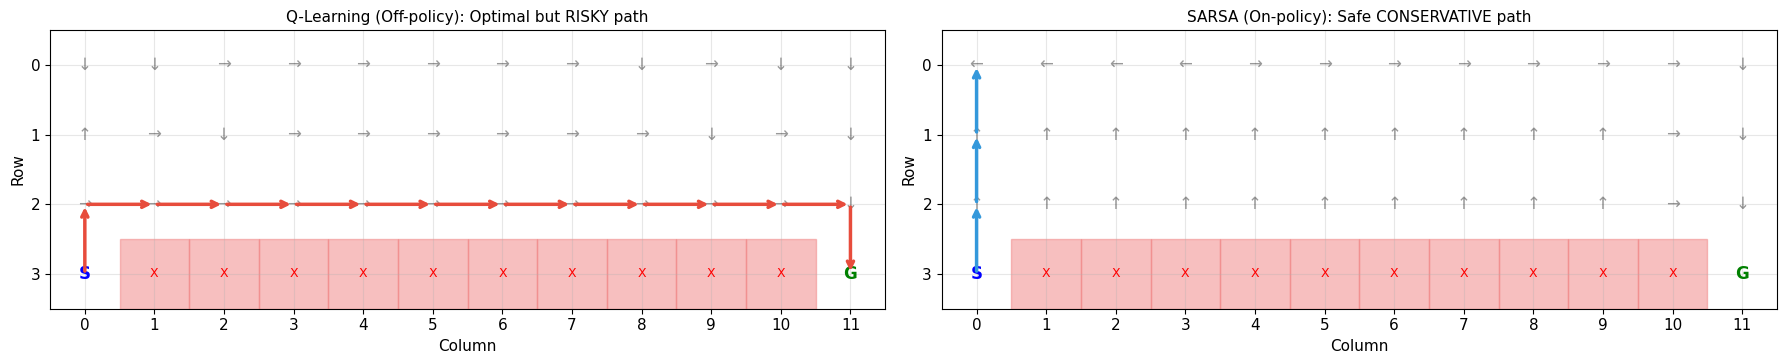

Saved: C:\Users\40270\OneDrive\Desktop\workspace\aisd\courses\rl\notes\week2_mdp_complete_demo_pages\fig2_path_comparison.png

Q-Learning path: (3, 0) → (2, 0) → (2, 1) → (2, 2) → (2, 3) → (2, 4) → (2, 5) → (2, 6) → (2, 7) → (2, 8) → (2, 9) → (2, 10) → (2, 11) → (3, 11)
SARSA path:      (3, 0) → (2, 0) → (1, 0) → (0, 0) → (0, 0) → (0, 0) → (0, 0) → (0, 0) → (0, 0) → (0, 0) → (0, 0) → (0, 0) → (0, 0) → (0, 0) → (0, 0) → (0, 0) → (0, 0) → (0, 0) → (0, 0) → (0, 0) → (0, 0) → (0, 0) → (0, 0) → (0, 0) → (0, 0) → (0, 0) → (0, 0) → (0, 0) → (0, 0) → (0, 0) → (0, 0) → (0, 0) → (0, 0) → (0, 0) → (0, 0) → (0, 0) → (0, 0) → (0, 0) → (0, 0) → (0, 0) → (0, 0) → (0, 0) → (0, 0) → (0, 0) → (0, 0) → (0, 0) → (0, 0) → (0, 0) → (0, 0) → (0, 0) → (0, 0)

Why different paths?
  Q-Learning (off-policy): Updates with max Q(S', a') — assumes final policy
    will be greedy (no random stumbles). So it learns the SHORTEST path, even
    if it runs right next to the cliff. During training, random exploration
  

In [7]:
# ============================================================
# 步骤 4：可视化 — 学到的路径对比
# Step 4: Visualization — Learned Path Comparison
# ============================================================
# Q-Learning 学到贴崖的最短路，SARSA 学到远离悬崖的保守路
# Q-Learning learns optimal path near cliff,
# SARSA learns safer path far from cliff

print("\n" + "=" * 60)
print("Step 4: Learned Policy Path Comparison")
print("=" * 60)


def extract_path(q_table, max_steps=50):
    """从 Q 表提取贪婪路径 / Extract greedy path from Q-table."""
    path = [state_to_idx(*CLIFF_START)]
    s = path[0]
    for _ in range(max_steps):
        a = np.argmax(q_table[s])
        ns, r, done = cliff_step(s, a)
        path.append(ns)
        if done:
            break
        s = ns
    return path


path_ql = extract_path(q_ql)
path_sarsa = extract_path(q_sarsa)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 4))

for ax, q_table, path, title, color in [
    (ax1, q_ql, path_ql, 'Q-Learning (Off-policy): Optimal but RISKY path', '#e74c3c'),
    (ax2, q_sarsa, path_sarsa, 'SARSA (On-policy): Safe CONSERVATIVE path', '#3498db')
]:
    # 绘制网格
    # Draw grid
    ax.set_xlim(-0.5, CLIFF_COLS - 0.5)
    ax.set_ylim(CLIFF_ROWS - 0.5, -0.5)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Column')
    ax.set_ylabel('Row')
    ax.set_xticks(range(CLIFF_COLS))
    ax.set_yticks(range(CLIFF_ROWS))
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

    # 绘制悬崖
    # Draw cliff
    for c in range(1, 11):
        ax.add_patch(plt.Rectangle((c - 0.5, 3 - 0.5), 1, 1, color='lightcoral', alpha=0.5))
        ax.text(c, 3, 'X', ha='center', va='center', fontsize=9, color='red')

    # 绘制起点和终点
    # Draw start and goal
    ax.text(0, 3, 'S', ha='center', va='center', fontsize=12, fontweight='bold', color='blue')
    ax.text(11, 3, 'G', ha='center', va='center', fontsize=12, fontweight='bold', color='green')

    # 绘制策略箭头
    # Draw policy arrows
    for r in range(CLIFF_ROWS):
        for c in range(CLIFF_COLS):
            if (r, c) == CLIFF_START or (r, c) == CLIFF_GOAL:
                continue
            if r == 3 and 1 <= c <= 10:
                continue
            idx = state_to_idx(r, c)
            arrow = ARROW_SYMBOLS[np.argmax(q_table[idx])]
            ax.text(c, r, arrow, ha='center', va='center', fontsize=12, alpha=0.4)

    # 绘制路径
    # Draw path
    for i in range(len(path) - 1):
        r1, c1 = idx_to_state(path[i])
        r2, c2 = idx_to_state(path[i + 1])
        ax.annotate('', xy=(c2, r2), xytext=(c1, r1),
                     arrowprops=dict(arrowstyle='->', color=color, lw=2.5))

plt.tight_layout()
fig_path = os.path.join(OUTPUT_DIR, 'fig2_path_comparison.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")

# 打印路径
# Print paths
print("\nQ-Learning path:", " → ".join(str(idx_to_state(s)) for s in path_ql))
print("SARSA path:     ", " → ".join(str(idx_to_state(s)) for s in path_sarsa))

# 解释区别
# Explain the difference
print("""
Why different paths?
  Q-Learning (off-policy): Updates with max Q(S', a') — assumes final policy
    will be greedy (no random stumbles). So it learns the SHORTEST path, even
    if it runs right next to the cliff. During training, random exploration
    causes frequent cliff falls, but the learned Q-values reflect the optimal
    (greedy) policy.

  SARSA (on-policy): Updates with Q(S', A') — A' is the actual next action
    from the SAME ε-greedy policy. Near the cliff, ε-greedy occasionally picks
    a random action that leads to -100. SARSA "feels" this risk in its updates,
    so it learns to stay AWAY from the cliff edge, even though the path is longer.

  📚 Ref: Sutton Example 6.6, p.132 (Figure 6.4)
""")

## Step 5: Reward Design Experiments


Step 5: Reward Design Experiments
  Negative (-1/step)    : last 30 avg reward =    -37.1, avg steps =  15.0


  Zero (0/step)         : last 30 avg reward =      0.0, avg steps = 500.0


  Positive (+1/step)    : last 30 avg reward =    500.0, avg steps = 500.0


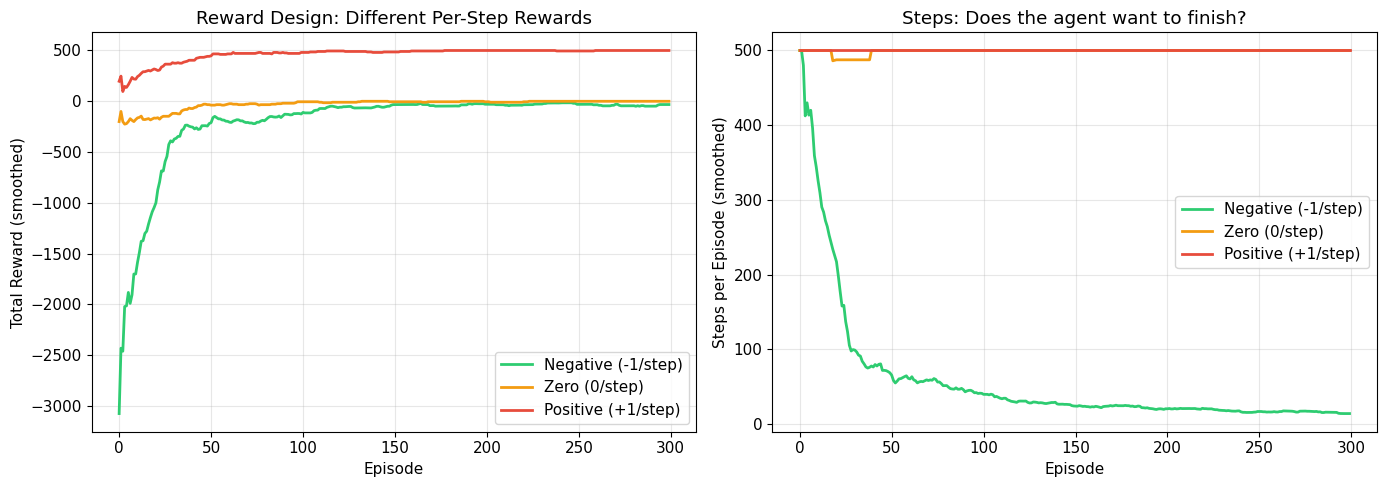

Saved: C:\Users\40270\OneDrive\Desktop\workspace\aisd\courses\rl\notes\week2_mdp_complete_demo_pages\fig3_reward_design.png

Key insight (Sutton p.53-54):
  - Negative per-step reward (-1): Agent hurries to goal (fewer penalties)
  - Zero per-step reward (0): Agent has no incentive to hurry (may wander)
  - Positive per-step reward (+1): Agent AVOIDS the goal! Every step earns
    reward, so termination means losing future income → agent wanders forever.
  ⚠️ This is why reward design encodes WHAT you want, not HOW.



In [8]:
# ============================================================
# 步骤 5：奖励设计实验
# Step 5: Reward Design Experiments
# ============================================================
# 📚 Ref: Sutton §3.2, p.53-54; Slides Page 12
# 正确设计奖励是 RL 的关键：奖励编码"想实现什么"，不是"如何实现"
# Proper reward design is critical: rewards encode WHAT, not HOW

print("\n" + "=" * 60)
print("Step 5: Reward Design Experiments")
print("=" * 60)

reward_configs = {
    'Negative (-1/step)': -1,
    'Zero (0/step)': 0,
    'Positive (+1/step)': 1,
}

EXP_EPISODES = 300
reward_results = {}

for name, step_r in reward_configs.items():
    _, rewards, steps = train_q_learning(
        episodes=EXP_EPISODES, step_reward=step_r,
        eps_start=0.5, eps_decay=0.99, eps_min=0.01
    )
    reward_results[name] = (rewards, steps)
    avg_r = np.mean(rewards[-30:])
    avg_s = np.mean(steps[-30:])
    print(f"  {name:<22}: last 30 avg reward = {avg_r:>8.1f}, avg steps = {avg_s:>5.1f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2ecc71', '#f39c12', '#e74c3c']

for (name, (rewards, steps)), color in zip(reward_results.items(), colors):
    ax1.plot(rolling_mean(rewards, WINDOW), label=name, color=color, linewidth=2)
    ax2.plot(rolling_mean(steps, WINDOW), label=name, color=color, linewidth=2)

ax1.set_xlabel('Episode')
ax1.set_ylabel('Total Reward (smoothed)')
ax1.set_title('Reward Design: Different Per-Step Rewards')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Episode')
ax2.set_ylabel('Steps per Episode (smoothed)')
ax2.set_title('Steps: Does the agent want to finish?')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
fig_path = os.path.join(OUTPUT_DIR, 'fig3_reward_design.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")

print("""
Key insight (Sutton p.53-54):
  - Negative per-step reward (-1): Agent hurries to goal (fewer penalties)
  - Zero per-step reward (0): Agent has no incentive to hurry (may wander)
  - Positive per-step reward (+1): Agent AVOIDS the goal! Every step earns
    reward, so termination means losing future income → agent wanders forever.
  ⚠️ This is why reward design encodes WHAT you want, not HOW.
""")

## Step 6: Bellman Equation Hand Calculation Verification

In [9]:
# ============================================================
# 步骤 6：Bellman 方程手算验证
# Step 6: Bellman Equation Hand Calculation Verification
# ============================================================
# 📚 Ref: Sutton §3.5, Eq. 3.14; David Silver L2 Slides 19-20
# v_π(s) = Σ_a π(a|s) Σ_{s',r} p(s',r|s,a) [r + γ v_π(s')]
# 在确定性环境中简化为：v_π(s) = Σ_a π(a|s) [r(s,a) + γ v_π(s')]

print("\n" + "=" * 60)
print("Step 6: Bellman Equation Step-by-Step Verification")
print("=" * 60)

# 用训练好的 Q-Learning Q 表验证 Bellman 方程
# Verify Bellman equation using trained Q-Learning Q-table
test_state = state_to_idx(2, 5)  # 悬崖上方的一个普通状态
r_test, c_test = idx_to_state(test_state)

print(f"\nVerifying Bellman equation at state ({r_test},{c_test}) [index={test_state}]")
print(f"Q-values from trained Q-table:")
for a in range(NUM_ACTIONS):
    print(f"  Q(s, {ACTION_NAMES[a]:>5}) = {q_ql[test_state][a]:>8.3f}")

print(f"\nV(s) = max_a Q(s,a) = {np.max(q_ql[test_state]):.3f}")
best_a = np.argmax(q_ql[test_state])
print(f"Best action: {ACTION_NAMES[best_a]}")

# 验证 Q(s,a) ≈ r + γ max_a' Q(s', a')
# Verify Q(s,a) ≈ r + γ max_a' Q(s', a')
print(f"\nBellman check for each action:")
print(f"{'Action':>6} | {'Q(s,a)':>8} | {'r':>5} | {'s_next':>6} | {'γ·maxQ(s_next)':>14} | {'r + γ·maxQ':>10} | {'Match?':>7}")
print("-" * 75)

for a in range(NUM_ACTIONS):
    ns, r, done = cliff_step(test_state, a)
    gamma_max_q = GAMMA * np.max(q_ql[ns]) if not done else 0
    bellman_rhs = r + gamma_max_q
    q_val = q_ql[test_state][a]
    match = "✅" if abs(q_val - bellman_rhs) < 1.0 else "≈"  # 近似（采样误差）
    nr, nc = idx_to_state(ns)
    print(f"{ACTION_NAMES[a]:>6} | {q_val:>8.3f} | {r:>5} | ({nr},{nc:>2}) | {gamma_max_q:>14.3f} | {bellman_rhs:>10.3f} | {match:>7}")

print("""
Note: Q-values approximately satisfy the Bellman equation. Small differences
are expected because Q-Learning uses sampled updates (not exact computation).
With enough training, Q(s,a) → r + γ max_a' Q(s', a') for all (s, a).
📚 Ref: Sutton §3.6, Eq. 3.20 (Bellman optimality equation for q*)
""")


Step 6: Bellman Equation Step-by-Step Verification

Verifying Bellman equation at state (2,5) [index=29]
Q-values from trained Q-table:
  Q(s,    Up) =   -5.662
  Q(s,  Down) = -106.442
  Q(s,  Left) =   -5.686
  Q(s, Right) =   -4.686

V(s) = max_a Q(s,a) = -4.686
Best action: Right

Bellman check for each action:
Action |   Q(s,a) |     r | s_next | γ·maxQ(s_next) | r + γ·maxQ |  Match?
---------------------------------------------------------------------------
    Up |   -5.662 |    -1 | (1, 5) |         -4.688 |     -5.688 |       ✅
  Down | -106.442 |  -100 | (3, 0) |         -6.458 |   -106.458 |       ✅
  Left |   -5.686 |    -1 | (2, 4) |         -4.695 |     -5.695 |       ✅
 Right |   -4.686 |    -1 | (2, 6) |         -3.686 |     -4.686 |       ✅

Note: Q-values approximately satisfy the Bellman equation. Small differences
are expected because Q-Learning uses sampled updates (not exact computation).
With enough training, Q(s,a) → r + γ max_a' Q(s', a') for all (s, a).
📚 Ref

## Step 7: Discount Factor Experiments


Step 7: Discount Factor γ Experiments
  γ = 0.1 : last 30 avg steps = 16.2


  γ = 0.5 : last 30 avg steps = 16.1
  γ = 0.9 : last 30 avg steps = 14.9
  γ = 0.99: last 30 avg steps = 14.2


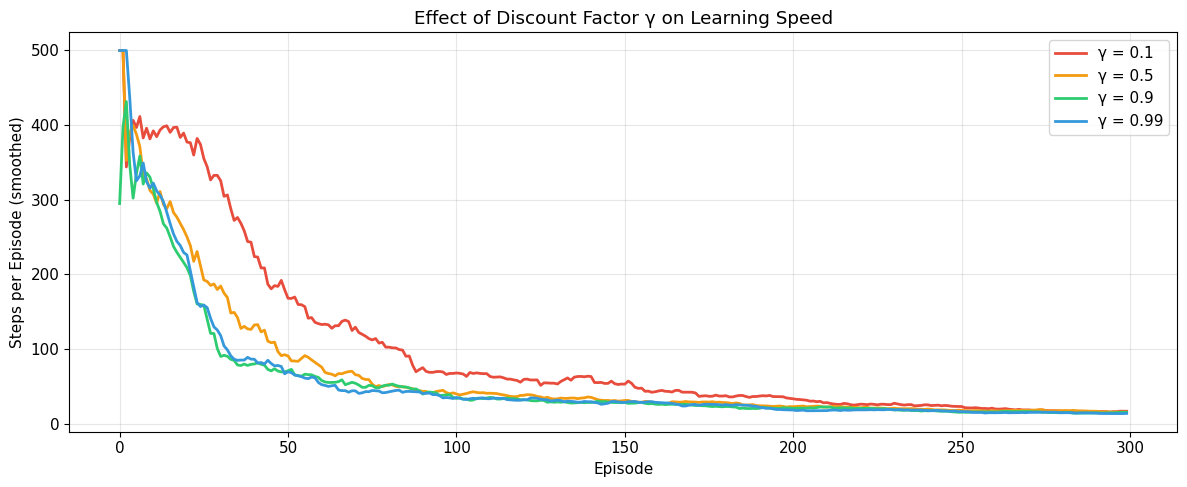

Saved: C:\Users\40270\OneDrive\Desktop\workspace\aisd\courses\rl\notes\week2_mdp_complete_demo_pages\fig4_gamma_comparison.png


In [10]:
# ============================================================
# 步骤 7：折扣因子实验
# Step 7: Discount Factor Experiments
# ============================================================
# 📚 Ref: Sutton §3.3; David Silver L2 Slides 12-13
# γ → 0: 近视（只看即时奖励）
# γ → 1: 远见（几乎同等重视所有奖励）

print("\n" + "=" * 60)
print("Step 7: Discount Factor γ Experiments")
print("=" * 60)

gamma_values = [0.1, 0.5, 0.9, 0.99]
gamma_results = {}

for g in gamma_values:
    _, rewards, steps = train_q_learning(
        episodes=300, gamma=g,
        eps_start=0.5, eps_decay=0.99, eps_min=0.01
    )
    gamma_results[g] = (rewards, steps)
    avg_s = np.mean(steps[-30:])
    print(f"  γ = {g:<4}: last 30 avg steps = {avg_s:.1f}")

fig, ax = plt.subplots(figsize=(12, 5))
colors_g = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db']

for (g, (rewards, steps)), color in zip(gamma_results.items(), colors_g):
    ax.plot(rolling_mean(steps, WINDOW), label=f'γ = {g}', color=color, linewidth=2)

ax.set_xlabel('Episode')
ax.set_ylabel('Steps per Episode (smoothed)')
ax.set_title('Effect of Discount Factor γ on Learning Speed')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig_path = os.path.join(OUTPUT_DIR, 'fig4_gamma_comparison.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")

## Step 8: On-policy vs Off-policy Update Demo (Single Step)

In [11]:
# ============================================================
# 步骤 8：On-policy vs Off-policy 更新对比（单步演示）
# Step 8: On-policy vs Off-policy Update Demo (Single Step)
# ============================================================
# 用一个具体的例子演示 Q-Learning 和 SARSA 更新的区别
# Demonstrate the difference with a concrete example

print("\n" + "=" * 60)
print("Step 8: Single-Step Update Comparison")
print("=" * 60)

# 模拟场景：状态 s, 执行动作 a='Right', 到达 s', 奖励 r=-1
# Scenario: state s, take action a='Right', reach s', reward r=-1
alpha_demo = 0.5
gamma_demo = 0.9

# 当前 Q 值
# Current Q-values
Q_s_a = 2.0                       # Q(s, Right) = 2.0
Q_s_prime = [1.0, 3.0, 0.5, 2.5]  # Q(s', [Up, Down, Left, Right])
r_demo = -1

# ε-greedy 实际选了 A' = Up（Q=1.0），不是 max（Q=3.0）
# ε-greedy actually chose A' = Up (Q=1.0), not max (Q=3.0)
A_prime_idx = 0  # Up
A_prime_name = "Up"

print(f"Scenario:")
print(f"  Q(s, Right)   = {Q_s_a}")
print(f"  R             = {r_demo}")
print(f"  Q(s', Up)     = {Q_s_prime[0]}")
print(f"  Q(s', Down)   = {Q_s_prime[1]}")
print(f"  Q(s', Left)   = {Q_s_prime[2]}")
print(f"  Q(s', Right)  = {Q_s_prime[3]}")
print(f"  α = {alpha_demo}, γ = {gamma_demo}")
print(f"  ε-greedy chose A' = {A_prime_name} (not max!)")

# Q-Learning 更新
# Q-Learning update
max_q_next = max(Q_s_prime)
td_target_ql = r_demo + gamma_demo * max_q_next
td_error_ql = td_target_ql - Q_s_a
new_Q_ql = Q_s_a + alpha_demo * td_error_ql

print(f"\n--- Q-Learning (off-policy) ---")
print(f"  TD target = R + γ max Q(S',a') = {r_demo} + {gamma_demo} × {max_q_next} = {td_target_ql}")
print(f"  TD error  = {td_target_ql} - {Q_s_a} = {td_error_ql}")
print(f"  New Q(s,a) = {Q_s_a} + {alpha_demo} × {td_error_ql} = {new_Q_ql}")

# SARSA 更新
# SARSA update
q_next_actual = Q_s_prime[A_prime_idx]
td_target_sarsa = r_demo + gamma_demo * q_next_actual
td_error_sarsa = td_target_sarsa - Q_s_a
new_Q_sarsa = Q_s_a + alpha_demo * td_error_sarsa

print(f"\n--- SARSA (on-policy) ---")
print(f"  TD target = R + γ Q(S',A') = {r_demo} + {gamma_demo} × {q_next_actual} = {td_target_sarsa}")
print(f"  TD error  = {td_target_sarsa} - {Q_s_a} = {td_error_sarsa}")
print(f"  New Q(s,a) = {Q_s_a} + {alpha_demo} × {td_error_sarsa} = {new_Q_sarsa}")

print(f"\n  Q-Learning updated to {new_Q_ql}, SARSA updated to {new_Q_sarsa}")
print(f"  Difference = {abs(new_Q_ql - new_Q_sarsa):.2f}")
print(f"  SARSA is more conservative because it uses the actual (worse) action value.")


Step 8: Single-Step Update Comparison
Scenario:
  Q(s, Right)   = 2.0
  R             = -1
  Q(s', Up)     = 1.0
  Q(s', Down)   = 3.0
  Q(s', Left)   = 0.5
  Q(s', Right)  = 2.5
  α = 0.5, γ = 0.9
  ε-greedy chose A' = Up (not max!)

--- Q-Learning (off-policy) ---
  TD target = R + γ max Q(S',a') = -1 + 0.9 × 3.0 = 1.7000000000000002
  TD error  = 1.7000000000000002 - 2.0 = -0.2999999999999998
  New Q(s,a) = 2.0 + 0.5 × -0.2999999999999998 = 1.85

--- SARSA (on-policy) ---
  TD target = R + γ Q(S',A') = -1 + 0.9 × 1.0 = -0.09999999999999998
  TD error  = -0.09999999999999998 - 2.0 = -2.1
  New Q(s,a) = 2.0 + 0.5 × -2.1 = 0.95

  Q-Learning updated to 1.85, SARSA updated to 0.95
  Difference = 0.90
  SARSA is more conservative because it uses the actual (worse) action value.


## Step 9: Value Function Heatmap Comparison


Step 9: Value Function Heatmap — Q-Learning vs SARSA


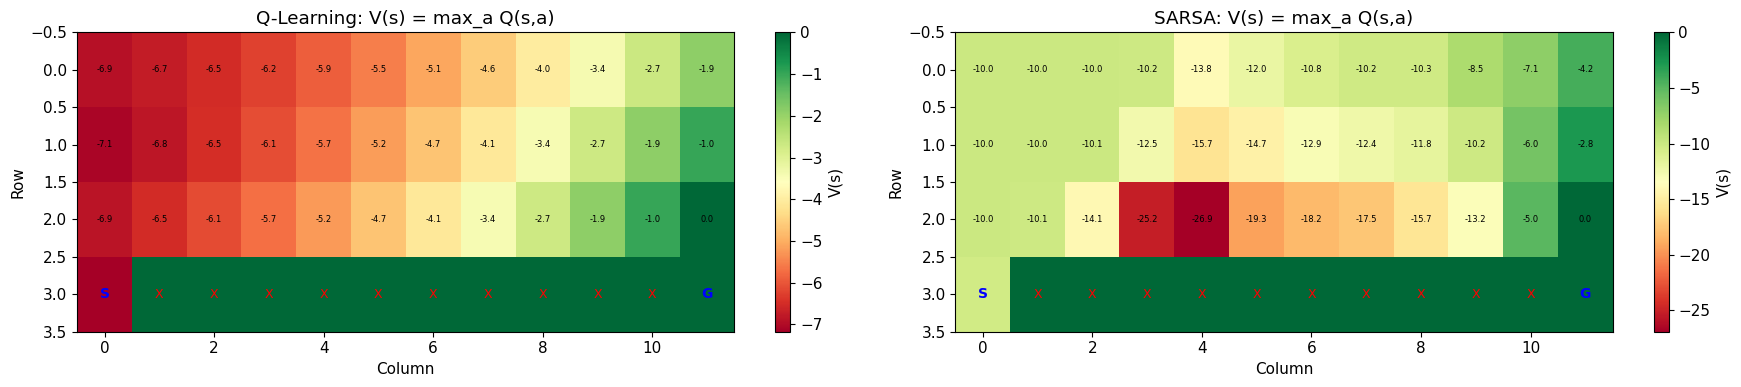

Saved: C:\Users\40270\OneDrive\Desktop\workspace\aisd\courses\rl\notes\week2_mdp_complete_demo_pages\fig5_value_heatmap.png


In [12]:
# ============================================================
# 步骤 9：综合可视化 — 价值函数热力图对比
# Step 9: Value Function Heatmap Comparison
# ============================================================
print("\n" + "=" * 60)
print("Step 9: Value Function Heatmap — Q-Learning vs SARSA")
print("=" * 60)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 4))

for ax, q_table, title in [
    (ax1, q_ql, 'Q-Learning: V(s) = max_a Q(s,a)'),
    (ax2, q_sarsa, 'SARSA: V(s) = max_a Q(s,a)')
]:
    value_grid = np.zeros((CLIFF_ROWS, CLIFF_COLS))
    for r in range(CLIFF_ROWS):
        for c in range(CLIFF_COLS):
            value_grid[r, c] = np.max(q_table[state_to_idx(r, c)])

    im = ax.imshow(value_grid, cmap='RdYlGn', aspect='auto')
    ax.set_title(title)
    ax.set_xlabel('Column')
    ax.set_ylabel('Row')
    plt.colorbar(im, ax=ax, label='V(s)')

    for r in range(CLIFF_ROWS):
        for c in range(CLIFF_COLS):
            if (r, c) == CLIFF_START:
                ax.text(c, r, 'S', ha='center', va='center', fontsize=10, fontweight='bold', color='blue')
            elif (r, c) == CLIFF_GOAL:
                ax.text(c, r, 'G', ha='center', va='center', fontsize=10, fontweight='bold', color='blue')
            elif r == 3 and 1 <= c <= 10:
                ax.text(c, r, 'X', ha='center', va='center', fontsize=9, color='red')
            else:
                ax.text(c, r, f'{value_grid[r, c]:.1f}', ha='center', va='center', fontsize=6)

plt.tight_layout()
fig_path = os.path.join(OUTPUT_DIR, 'fig5_value_heatmap.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")

## Summary

In [13]:
# ============================================================
# 总结
# Summary
# ============================================================
print("\n" + "=" * 60)
print("Summary: Week 2 Key Takeaways")
print("=" * 60)
print("""
1. MDP = ⟨S, A, P, R, γ⟩ — formal framework for RL problems
   📚 Sutton §3.1; Silver L2 Slide 24

2. Q-Learning (off-policy) vs SARSA (on-policy):
   - Q-Learning: max Q(S',a') → optimal but ignores exploration risk
   - SARSA: Q(S',A') → considers exploration risk, learns safer paths
   📚 Sutton §6.4-6.5; Slides Pages 6-7

3. Reward design matters:
   - Negative per-step → shortest path
   - Positive per-step → agent avoids termination!
   📚 Sutton §3.2, p.53-54

4. Bellman equation: V(s) = E[R + γV(S')]
   - Q-Learning approximates Bellman optimality (q*)
   - SARSA approximates Bellman expectation (q_π)
   📚 Sutton §3.5-3.6; Silver L2 Slides 19-48

5. Discount γ:
   - γ→0: myopic (only immediate reward)
   - γ→1: far-sighted (all rewards matter)
   📚 Sutton §3.3; Silver L2 Slides 12-13
""")

print("All visualizations saved to:")
print(f"  {OUTPUT_DIR}")
print("=" * 60)


Summary: Week 2 Key Takeaways

1. MDP = ⟨S, A, P, R, γ⟩ — formal framework for RL problems
   📚 Sutton §3.1; Silver L2 Slide 24

2. Q-Learning (off-policy) vs SARSA (on-policy):
   - Q-Learning: max Q(S',a') → optimal but ignores exploration risk
   - SARSA: Q(S',A') → considers exploration risk, learns safer paths
   📚 Sutton §6.4-6.5; Slides Pages 6-7

3. Reward design matters:
   - Negative per-step → shortest path
   - Positive per-step → agent avoids termination!
   📚 Sutton §3.2, p.53-54

4. Bellman equation: V(s) = E[R + γV(S')]
   - Q-Learning approximates Bellman optimality (q*)
   - SARSA approximates Bellman expectation (q_π)
   📚 Sutton §3.5-3.6; Silver L2 Slides 19-48

5. Discount γ:
   - γ→0: myopic (only immediate reward)
   - γ→1: far-sighted (all rewards matter)
   📚 Sutton §3.3; Silver L2 Slides 12-13

All visualizations saved to:
  C:\Users\40270\OneDrive\Desktop\workspace\aisd\courses\rl\notes\week2_mdp_complete_demo_pages
